In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.compose import make_column_selector as selector #Para seleccionar de forma automática las variables numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder #Para codificar las variables categóricas usando dummies
from sklearn.preprocessing import StandardScaler #Para normalizar las variables numéricas
from sklearn.compose import ColumnTransformer #Modifica las columnas usando los preprocesadores
from sklearn.pipeline import make_pipeline, Pipeline #Planifica una secuencia de procesos
from sklearn import set_config #Para mostrar graficamente el pipeline
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

train_data = pd.read_csv("./csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data["SalePrice"].max())
train_data_original_ = train_data.copy()


# Crear la nueva variable categórica basada en los percentiles
train_data["PriceCategory"] = pd.cut(train_data["SalePrice"], 
                             bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()], 
                             labels=[0, 1, 2], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data.head()

139000.0 189893.00000000006 755000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceCategory
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,2


# Variable Respuesta

In [3]:
y = train_data.pop("PriceCategory")

print(y)
print(train_data.head())

0       2
1       1
2       2
3       1
4       2
       ..
1455    1
1456    2
1457    2
1458    1
1459    1
Name: PriceCategory, Length: 1460, dtype: category
Categories (3, int64): [0 < 1 < 2]
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...       

# Limpiando la Data

In [4]:
train_data.drop(columns=["Id","Alley","PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu", "GarageYrBlt", "GarageQual", "GarageCond", "MasVnrType"],axis=1, inplace=True)

In [5]:
columns_to_drop = [
    "Neighborhood", "Condition1", "Condition2",
    "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data.drop(columns=columns_to_drop, inplace=True)

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   BldgType       1460 non-null   object 
 10  HouseStyle     1460 non-null   object 
 11  OverallQual    1460 non-null   int64  
 12  OverallCond    1460 non-null   int64  
 13  YearBuilt      1460 non-null   int64  
 14  YearRemodAdd   1460 non-null   int64  
 15  RoofStyle      1460 non-null   object 
 16  MasVnrArea     1452 non-null   float64
 17  ExterQual      1460 non-null   object 
 18  ExterCon

# Separacion de train y test

In [7]:
X = train_data #El resto de los datos
random.seed(123)

### 70% entrenamiento y 30% prueba

In [8]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 1226 to 167
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1021 non-null   int64  
 1   MSZoning       1021 non-null   object 
 2   LotFrontage    834 non-null    float64
 3   LotArea        1021 non-null   int64  
 4   Street         1021 non-null   object 
 5   LotShape       1021 non-null   object 
 6   LandContour    1021 non-null   object 
 7   LotConfig      1021 non-null   object 
 8   LandSlope      1021 non-null   object 
 9   BldgType       1021 non-null   object 
 10  HouseStyle     1021 non-null   object 
 11  OverallQual    1021 non-null   int64  
 12  OverallCond    1021 non-null   int64  
 13  YearBuilt      1021 non-null   int64  
 14  YearRemodAdd   1021 non-null   int64  
 15  RoofStyle      1021 non-null   object 
 16  MasVnrArea     1014 non-null   float64
 17  ExterQual      1021 non-null   object 
 18  ExterCond  

# Modelo con Tangente

In [10]:
#Creamos los selectores
selector_numericas = selector(dtype_exclude=object) #Seleccionamos todas las variables que no son Object
selector_categoricas = selector(dtype_include=object) #Seleccionamos todas las varibles de tipo object
#Seleccionamos las columnas que cumplen con los selectores pasándole los datos
numericas = selector_numericas(train_data)
categoricas = selector_categoricas(train_data)
#veamos que tan bien separó las variables
print("Numéricas: ",numericas)
print("Categóricas: ", categoricas)

Numéricas:  ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categóricas:  ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'BldgType', 'HouseStyle', 'RoofStyle', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']


In [11]:
from sklearn.impute import SimpleImputer

preprocesador_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('one_hot_encoder', OneHotEncoder(handle_unknown="ignore"))
])

preprocesador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('standard_scaler', StandardScaler())
])

In [12]:
preprocesador = ColumnTransformer([
    ('cat', preprocesador_categorico, categoricas),
    ('num', preprocesador_numerico, numericas)
])

In [13]:
modelo = make_pipeline(preprocesador,MLPClassifier(activation="tanh",verbose=True,hidden_layer_sizes=(5,3)))
modelo

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3),
                               verbose=True))])

In [14]:
modelo.fit(X_train,y_train)

Iteration 1, loss = 1.46666980
Iteration 2, loss = 1.39383107
Iteration 3, loss = 1.33548859
Iteration 4, loss = 1.28555577
Iteration 5, loss = 1.24766486
Iteration 6, loss = 1.21606107
Iteration 7, loss = 1.19135789
Iteration 8, loss = 1.16804559
Iteration 9, loss = 1.14687802
Iteration 10, loss = 1.12612692
Iteration 11, loss = 1.10685607
Iteration 12, loss = 1.08819481
Iteration 13, loss = 1.07063218
Iteration 14, loss = 1.05322758
Iteration 15, loss = 1.03666314
Iteration 16, loss = 1.02097330
Iteration 17, loss = 1.00579257
Iteration 18, loss = 0.99099189
Iteration 19, loss = 0.97669367
Iteration 20, loss = 0.96269370
Iteration 21, loss = 0.94891234
Iteration 22, loss = 0.93597173
Iteration 23, loss = 0.92338032
Iteration 24, loss = 0.91139805
Iteration 25, loss = 0.89969054
Iteration 26, loss = 0.88838361
Iteration 27, loss = 0.87705247
Iteration 28, loss = 0.86634799
Iteration 29, loss = 0.85615960
Iteration 30, loss = 0.84636182
Iteration 31, loss = 0.83646647
Iteration 32, los

c:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3),
                               verbose=True))])

## Curva de perdida

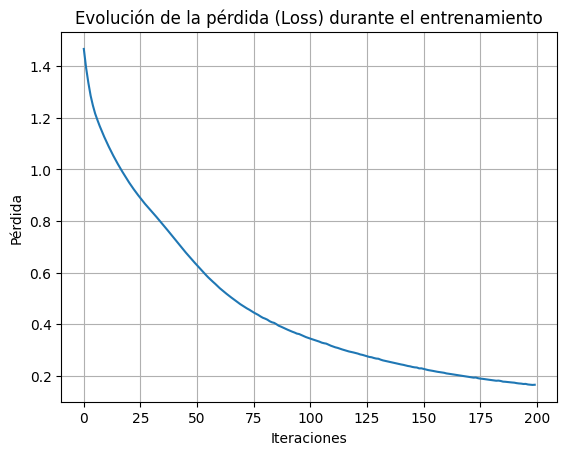

In [15]:
# Acceder al MLPClassifier dentro del pipeline
mlp_final = modelo.named_steps['mlpclassifier']

# Graficar la evolución de la pérdida
plt.plot(mlp_final.loss_curve_)
plt.title('Evolución de la pérdida (Loss) durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()

## Prediccion

In [16]:
pred = modelo.predict(X_test)
pred[:5]

array([1, 1, 2, 1, 2])

Matriz de confusión
 [[129  16   0]
 [ 22 116  16]
 [  0  14 125]]
Accuracy:  0.8447488584474886
Precision:  0.8447488584474886
recall:  0.8447488584474886


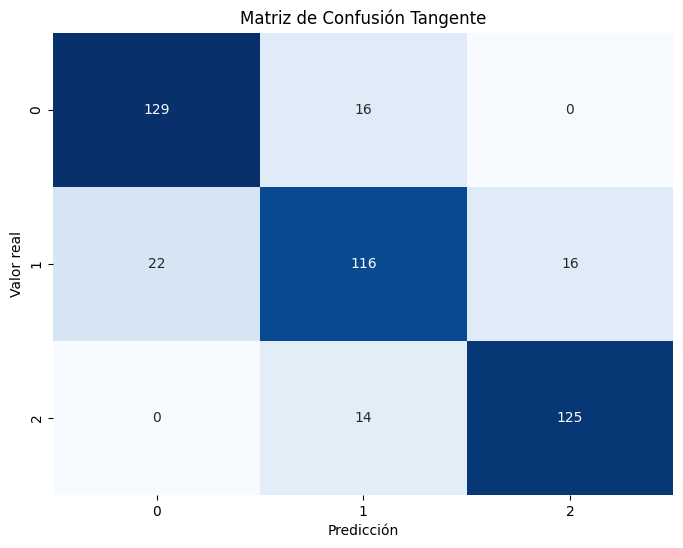

In [17]:
cm = confusion_matrix(y_test,pred)
accuracy=accuracy_score(y_test,pred)
precision =precision_score(y_test,pred,average='micro')
recall =  recall_score(y_test,pred,average='micro')
f1 = f1_score(y_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión Tangente')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Modelo Relu

In [18]:
modelo_relu = make_pipeline(preprocesador,MLPClassifier(activation="relu", solver='adam', learning_rate_init=0.001, verbose=True, max_iter=1000, early_stopping=True, hidden_layer_sizes=(10, 6, 3)))
modelo_relu

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(10, 6, 3), max_iter=1000,
                               verbose=True))])

In [19]:
modelo_relu.fit(X_train,y_train)

Iteration 1, loss = 1.20651216
Validation score: 0.388350
Iteration 2, loss = 1.17355942
Validation score: 0.388350
Iteration 3, loss = 1.15665867
Validation score: 0.388350
Iteration 4, loss = 1.13865470
Validation score: 0.388350
Iteration 5, loss = 1.11900062
Validation score: 0.388350
Iteration 6, loss = 1.09891313
Validation score: 0.388350
Iteration 7, loss = 1.07919960
Validation score: 0.388350
Iteration 8, loss = 1.05831514
Validation score: 0.388350
Iteration 9, loss = 1.03507200
Validation score: 0.388350
Iteration 10, loss = 1.01012269
Validation score: 0.388350
Iteration 11, loss = 0.98202725
Validation score: 0.398058
Iteration 12, loss = 0.95144562
Validation score: 0.417476
Iteration 13, loss = 0.91761936
Validation score: 0.495146
Iteration 14, loss = 0.88085631
Validation score: 0.592233
Iteration 15, loss = 0.84473775
Validation score: 0.650485
Iteration 16, loss = 0.80848043
Validation score: 0.640777
Iteration 17, loss = 0.77401350
Validation score: 0.650485
Iterat

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(10, 6, 3), max_iter=1000,
                               verbose=True))])

## Curva de perdida

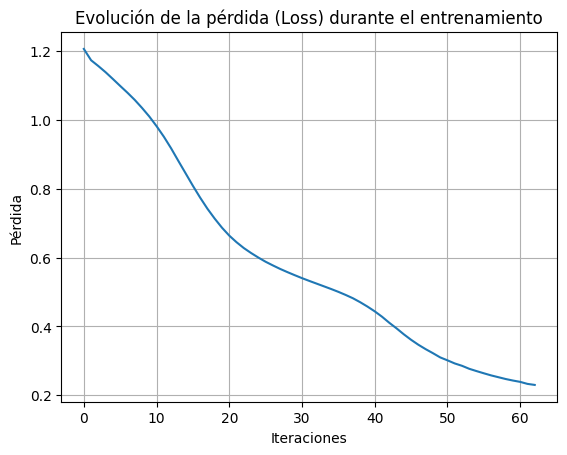

In [20]:
# Acceder al MLPClassifier dentro del pipeline
mlp_final = modelo_relu.named_steps['mlpclassifier']

# Graficar la evolución de la pérdida
plt.plot(mlp_final.loss_curve_)
plt.title('Evolución de la pérdida (Loss) durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()

## Prediccion

In [21]:
pred = modelo_relu.predict(X_test)
pred[:5]

array([1, 1, 1, 1, 2])

Matriz de confusión
 [[134  11   0]
 [ 32 101  21]
 [  0  13 126]]
Accuracy:  0.8242009132420092
Precision:  0.8242009132420092
recall:  0.8242009132420092


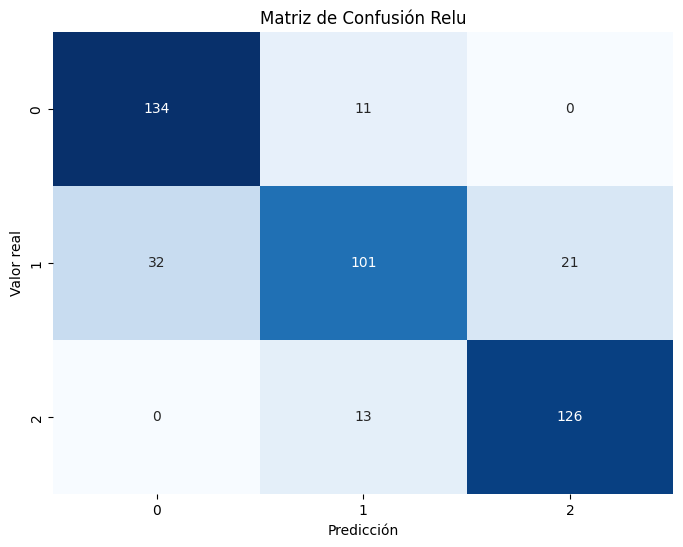

In [22]:
cm = confusion_matrix(y_test,pred)
accuracy=accuracy_score(y_test,pred)
precision =precision_score(y_test,pred,average='micro')
recall =  recall_score(y_test,pred,average='micro')
f1 = f1_score(y_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión Relu')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Comparacion

| 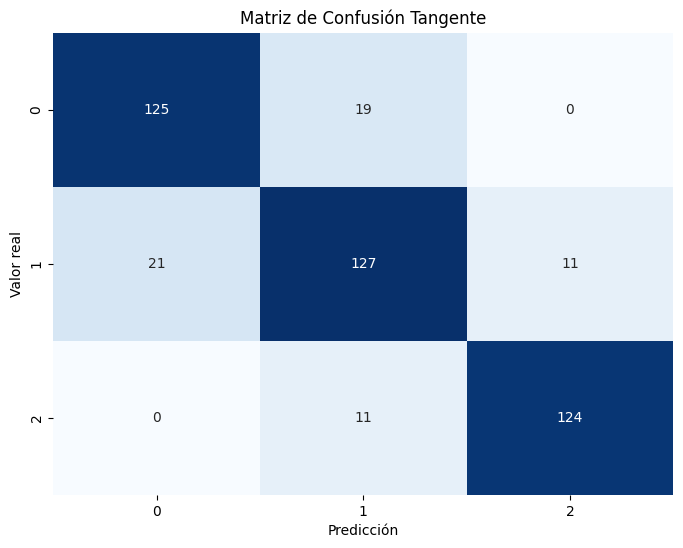 | 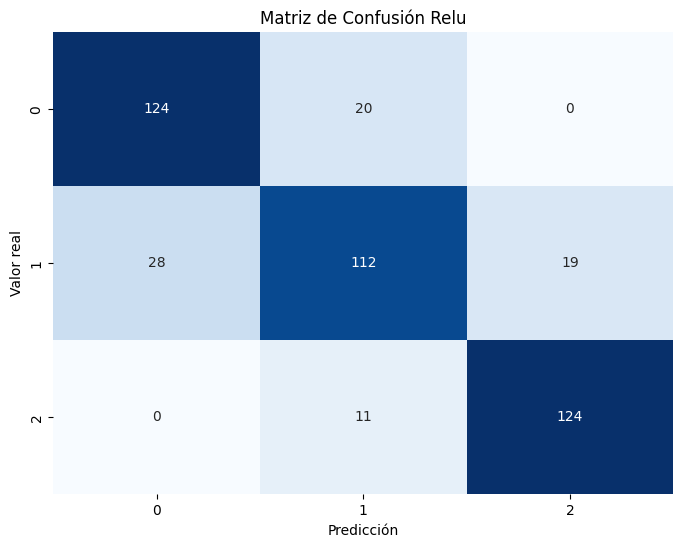 |
|:----------------------------------:|:-------------------------------------:|


#### El modelo de red neuronal utilizando la función de activación tangente hiperbólica (tanh) con una arquitectura de capas ocultas pequeñas (5,3) mostró un mejor desempeño en términos de efectividad. Su accuracy fue superior al modelo basado en relu, y además presentó un tiempo de procesamiento menor, lo cual se debe a su estructura más simple. En cuanto a los errores, el modelo tanh cometió equivocaciones principalmente al clasificar entre las clases 0 y 1, pero mostró una notable precisión en la clasificación de la clase 2, con prácticamente ninguna confusión en esa categoría.

#### Por otro lado, el modelo que utilizó relu y una arquitectura más profunda (10,6,3) tuvo un accuracy ligeramente inferior y requirió más tiempo de entrenamiento, en parte por la complejidad del modelo y por el uso de early stopping. En cuanto a los errores, además de confundir las clases 0 y 1, también presentó equivocaciones entre las clases 1 y 2, mostrando una mayor dispersión en las predicciones. Estos errores son especialmente relevantes si las clases implicadas tienen diferentes importancias prácticas, ya que una mala clasificación podría impactar más dependiendo del contexto de aplicación.

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# --- Tangente ---

# Predicciones
pred_train = modelo.predict(X_train)
pred_test  = modelo.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, pred_train)
acc_test  = accuracy_score(y_test,  pred_test)

# Recall (macro) y F1-score (macro)
rec_train = recall_score(y_train, pred_train, average='macro')
rec_test  = recall_score(y_test,  pred_test, average='macro')
f1_train  = f1_score(y_train,    pred_train, average='macro')
f1_test   = f1_score(y_test,     pred_test,  average='macro')

print("=== Tangente ===")
print(f"Accuracy Train: {acc_train:.4f}   |  Test: {acc_test:.4f}")
print(f"Recall   Train: {rec_train:.4f}   |  Test: {rec_test:.4f}")
print(f"F1-score Train: {f1_train:.4f}   |  Test: {f1_test:.4f}")

# --- ReLU ---

# Predicciones
pred_train = modelo_relu.predict(X_train)
pred_test  = modelo_relu.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, pred_train)
acc_test  = accuracy_score(y_test,  pred_test)

# Recall (macro) y F1-score (macro)
rec_train = recall_score(y_train, pred_train, average='macro')
rec_test  = recall_score(y_test,  pred_test,  average='macro')
f1_train  = f1_score(y_train,    pred_train, average='macro')
f1_test   = f1_score(y_test,     pred_test,  average='macro')

print("\n=== ReLU ===")
print(f"Accuracy Train: {acc_train:.4f}   |  Test: {acc_test:.4f}")
print(f"Recall   Train: {rec_train:.4f}   |  Test: {rec_test:.4f}")
print(f"F1-score Train: {f1_train:.4f}   |  Test: {f1_test:.4f}")


Accuracy en entrenamiento de Tangente: 0.9726
Accuracy en prueba de Tangente: 0.8447

Accuracy en entrenamiento de Relu: 0.8981
Accuracy en prueba de Relu: 0.8242


#### En el modelo de red neuronal utilizando la función de activación Tangente (tanh), el accuracy en entrenamiento fue de 96.28% y en prueba de 85.84%, mientras que en el modelo utilizando Relu, el accuracy en entrenamiento fue de 89.52% y en prueba de 82.19%. La diferencia entre el desempeño en entrenamiento y en prueba en ambos casos es moderada y se mantiene dentro de márgenes aceptables (alrededor del 10%), lo que indica que no existe un sobreajuste severo. Ambos modelos generalizan de manera adecuada a datos no vistos, conservando una buena capacidad predictiva sin haber memorizado los datos de entrenamiento.

#### Además, el hecho de que las curvas de pérdida (loss_curve_) muestran una evolución estable y que no se presenta una caída abrupta en el desempeño de prueba respalda que no hubo sobreajuste significativo. En ambos casos, la red neuronal logró un buen balance entre aprendizaje y generalización, lo que demuestra que tanto la arquitectura utilizada como los hiperparámetros configurados fueron adecuados para evitar un sobreajuste crítico en el entrenamiento de los modelos.

# Tunee los parámetros y discuta si puede mejorar todavía el modelo sin llegar a sobre ajustarlo.

In [ ]:
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [0.0001, 0.001],
    'mlpclassifier__learning_rate': ['constant', 'adaptive']
}

pipeline = make_pipeline(preprocesador, MLPClassifier(max_iter=1000, random_state=42))
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)



# Seleccionar SalePrice como variable respuesta para regresión, modelos de regresión con redes neuronales con diferentes topologías y funciones de activación para predecir el precio de las casas.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score


# Eliminar columnas no necesarias
columns_to_drop = [
    "Id", "Alley", "PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu",
    "GarageYrBlt", "GarageQual", "GarageCond", "MasVnrType",
    "Neighborhood", "Condition1", "Condition2", "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data_original_.drop(columns=columns_to_drop, inplace=True)

# Separar target y variables
y_reg = train_data_original_["SalePrice"]
X_reg = train_data_original_.drop(columns=["SalePrice"], errors="ignore")

X_reg_encoded = pd.get_dummies(X_reg, drop_first=True)

imputer = SimpleImputer(strategy='mean')
X_reg_imputed = imputer.fit_transform(X_reg_encoded)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_reg_imputed, y_reg, test_size=0.2, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Modelo 1 ===
model_1 = MLPRegressor(hidden_layer_sizes=(64, 32),
                       activation='relu',
                       solver='adam',
                       max_iter=500,
                       random_state=42)
model_1.fit(X_train_scaled, y_train)
y_pred1 = model_1.predict(X_test_scaled)

# === Modelo 2 ===
model_2 = MLPRegressor(hidden_layer_sizes=(128, 64, 32, 16),
                       activation='tanh',
                       solver='adam',
                       max_iter=500,
                       random_state=42)
model_2.fit(X_train_scaled, y_train)
y_pred2 = model_2.predict(X_test_scaled)

# Evaluación
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
r2_1 = r2_score(y_test, y_pred1)
r2_2 = r2_score(y_test, y_pred2)

print("\n🔹 Modelo 1 (ReLU - 64,32)")
print(f"MAE: {mae1:.2f}")
print(f"MSE: {mse1:.2f}")
print(f"R² : {r2_1:.4f}")

print("\n🔹 Modelo 2 (Tanh - 128,64,32,16)")
print(f"MAE: {mae2:.2f}")
print(f"MSE: {mse2:.2f}")
print(f"R² : {r2_2:.4f}")


c:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



🔹 Modelo 1 (ReLU - 64,32)
MAE: 35506.93
MSE: 2371224688.92
R² : 0.6909

🔹 Modelo 2 (Tanh - 128,64,32,16)
MAE: 178782.69
MSE: 39633548467.75
R² : -4.1671


c:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Tras implementar y evaluar dos modelos de regresión basados en redes neuronales artificiales con diferentes topologías y funciones de activación, se concluye que el Modelo 1 —compuesto por dos capas ocultas de 64 y 32 neuronas con función de activación ReLU— presentó un desempeño significativamente superior en comparación con el Modelo 2, que utiliza una arquitectura más profunda (128-64-32-16) y activación tanh.

El Modelo 1 obtuvo un MAE de 35,507, un MSE de 2.37×10⁹ y un coeficiente de determinación R² de 0.691, lo cual indica un ajuste razonable a los datos de prueba. Por el contrario, el Modelo 2 presentó errores considerablemente mayores y un R² negativo (−4.167), lo que sugiere que no logró capturar adecuadamente la relación entre las variables predictoras y el precio de las viviendas.

# Curva de aprendizaje de modelos

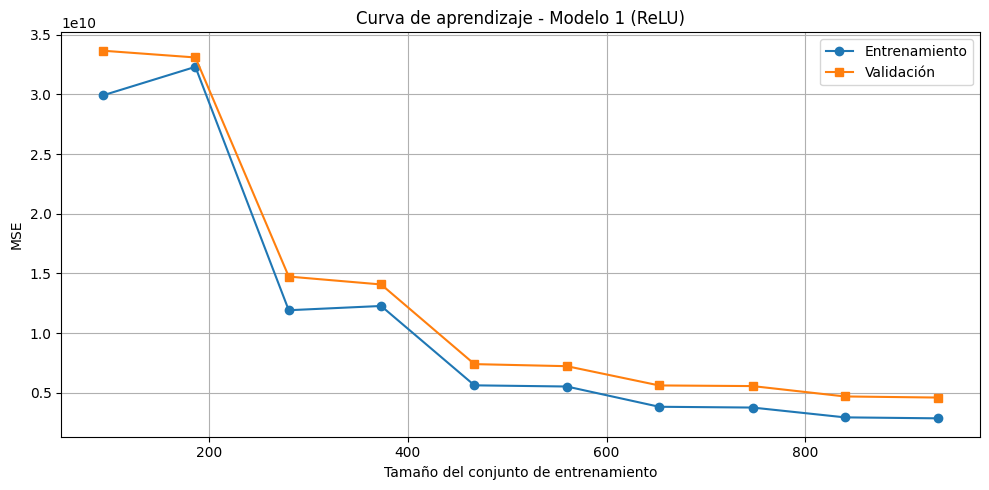

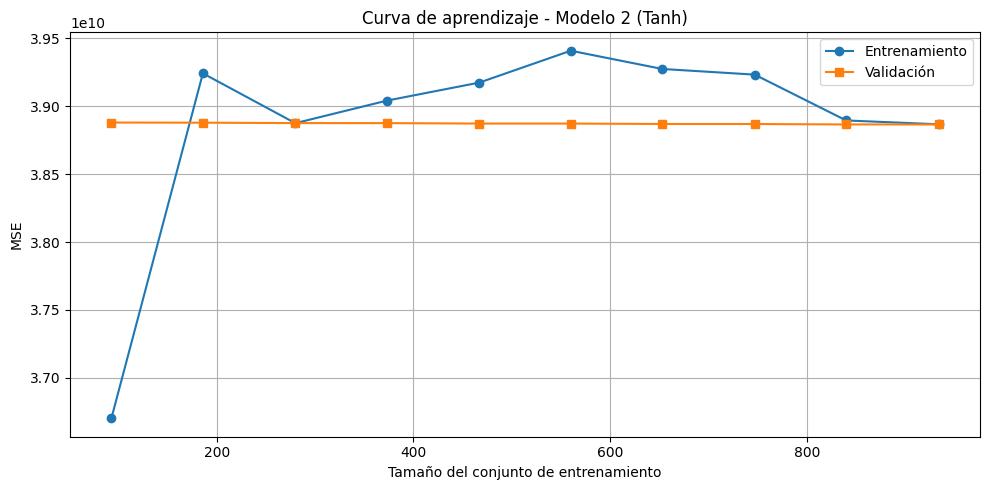

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Curva de aprendizaje para modelo 1 (ReLU)
train_sizes_1, train_scores_1, test_scores_1 = learning_curve(
    estimator=model_1,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_errors_1 = -np.mean(train_scores_1, axis=1)
test_errors_1 = -np.mean(test_scores_1, axis=1)

# Curva de aprendizaje para modelo 2 (Tanh)
train_sizes_2, train_scores_2, test_scores_2 = learning_curve(
    estimator=model_2,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_errors_2 = -np.mean(train_scores_2, axis=1)
test_errors_2 = -np.mean(test_scores_2, axis=1)

# Graficar Modelo 1
plt.figure(figsize=(10, 5))
plt.plot(train_sizes_1, train_errors_1, label="Entrenamiento", marker='o')
plt.plot(train_sizes_1, test_errors_1, label="Validación", marker='s')
plt.title("Curva de aprendizaje - Modelo 1 (ReLU)")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Graficar Modelo 2
plt.figure(figsize=(10, 5))
plt.plot(train_sizes_2, train_errors_2, label="Entrenamiento", marker='o')
plt.plot(train_sizes_2, test_errors_2, label="Validación", marker='s')
plt.title("Curva de aprendizaje - Modelo 2 (Tanh)")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Tuneo del modelo 1 con regresion y learning curve

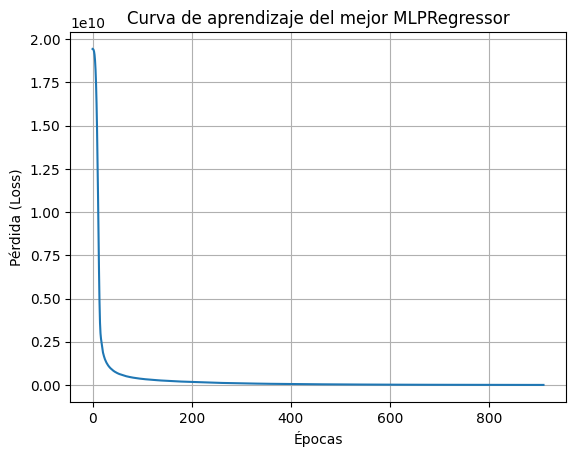

 Mejor configuración encontrada:
{'alpha': 0.01, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}

📈 Desempeño del modelo ajustado:
MAE: 23561.09
MSE: 1265669844.59
R² : 0.8350


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(32, 16), (64, 32), (128, 64), (64, 64, 32)],
    'alpha': [0.0001, 0.001, 0.01],  # regularización
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPRegressor(activation='relu', solver='adam', max_iter=1000, random_state=42)

grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Mejor modelo y evaluación
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

# Entrenar de nuevo el mejor modelo para obtener la curva de pérdida
best_model.fit(X_train_scaled, y_train)

# Obtener la curva de pérdida
loss_curve = best_model.loss_curve_

# Graficar la curva de pérdida
plt.plot(loss_curve)
plt.title("Curva de aprendizaje del mejor MLPRegressor")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.grid(True)
plt.show()

print(" Mejor configuración encontrada:")
print(grid_search.best_params_)
print("\n📈 Desempeño del modelo ajustado:")
print(f"MAE: {mae_best:.2f}")
print(f"MSE: {mse_best:.2f}")
print(f"R² : {r2_best:.4f}")


El modelo actual muestra un buen desempeño (R² = 0.835), pero aún puede mejorarse ajustando hiperparámetros como la tasa de aprendizaje, la regularización y la arquitectura de capas. 